<h1 align="center">Quantiles extrêmes</h1>

Le but de ce notebook est de mettre en pratique les deux premières séances du cours sur la théorie des quantiles extrêmes. Nous allons donc nous intéresser dans un premier temps à une distribution unidimensionnelle pour l'instant. Fidèle à l'exemple évoqué en cours, nous allons appliquer ces résultats à l'historique de l'élévation du niveau de la *Marne à Gournay-sur-Marne* (Les données sont disponibles sur le site [HydroPortail](https://hydro.eaufrance.fr/)). Plus particulièrement, nous allons identifier le **domaine d'attraction** de cette distribution (*Fréchet*, *Weibull* ou *Gumbel*), estimer les **paramètres de la distribution limite**, et enfin estimer les **quantiles extrêmes** de cette distribution.

L'ajout de la notion de dépendance dans un modèle multidimensionnel est plus délicat, et nous y reviendrons dans un second temps, avec l'utilisation des **copules** dans un autre jupyter notebook.

# Récupération des données

Commençons par récupérer les données. 

Le fichier `provenance_donnees.md` permet de tracher chaque fichier de données utilisés pour ce projet.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

In [7]:
marne_gournay = pd.read_csv("./data/F664000104-Marne-Gournay_sur_Marne_Pont.csv", sep=";")
# The first columb contains the date in the format "YYYY-MM-DD HH:MM:SS", we convert it to a datetime object
marne_gournay["DateTime"] = pd.to_datetime(marne_gournay["DateTime"], format="%Y-%m-%d %H:%M:%S")
# The second column contains the elevation of the water in mm, we convert it to a float
marne_gournay["F664000104"] = marne_gournay["F664000104"].astype(float)
marne_gournay.head()

,DateTime,F664000104
0,2026-02-24 08:50:00,4253.0
1,2026-02-24 09:00:00,4246.0
2,2026-02-24 09:10:00,4250.0
3,2026-02-24 09:20:00,4250.0
4,2026-02-24 09:30:00,4255.0


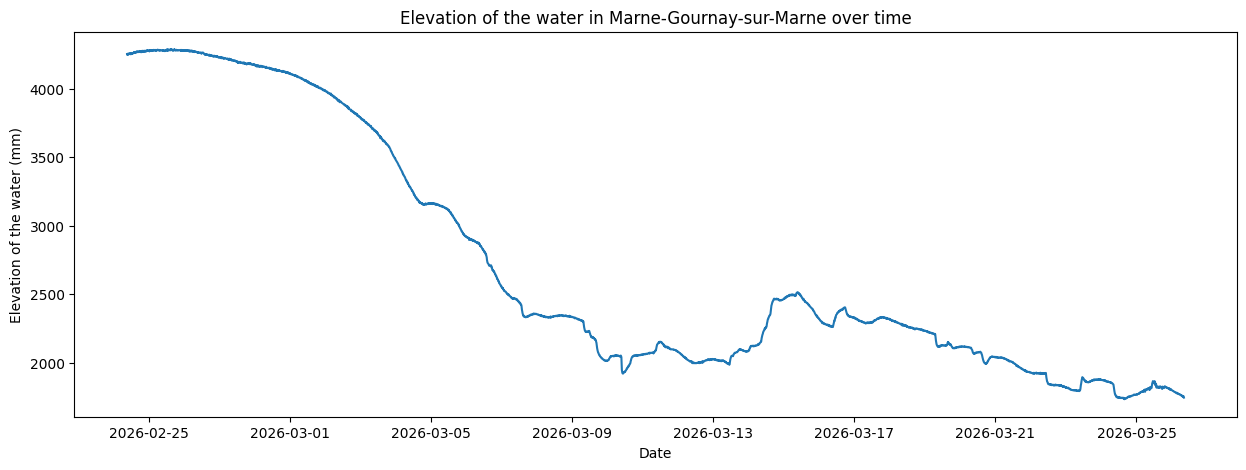

In [8]:
# Now draw a plot of the elevation of the water over time
plt.figure(figsize=(15, 5))
plt.plot(marne_gournay["DateTime"], marne_gournay["F664000104"])
plt.xlabel("Date")
plt.ylabel("Elevation of the water (mm)")
plt.title("Elevation of the water in Marne-Gournay-sur-Marne over time")
plt.show()

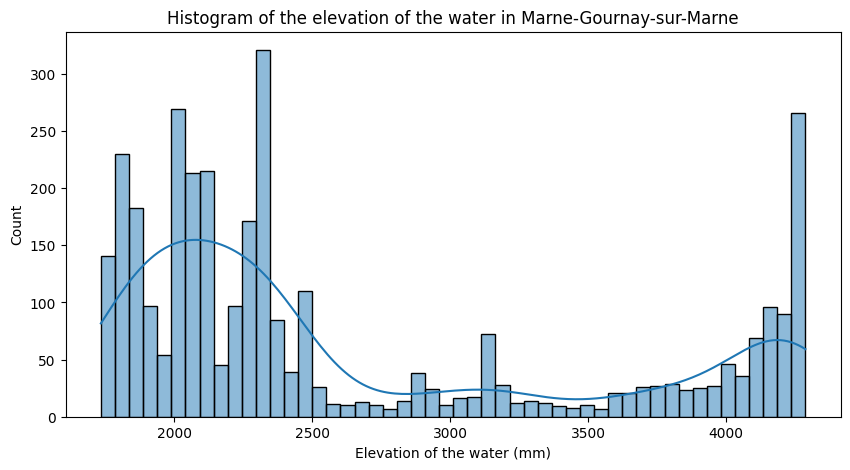

In [9]:
# Draw a histogram of the elevation of the water
plt.figure(figsize=(10, 5))
sns.histplot(marne_gournay["F664000104"], bins=50, kde=True)
plt.xlabel("Elevation of the water (mm)")
plt.title("Histogram of the elevation of the water in Marne-Gournay-sur-Marne")
plt.show()